In [2]:
import pandas as pd 
import numpy as np 

df = pd.read_csv("Cor_data.csv")

y = df["Cath"].map({
    "Cad": 1,
    "Normal": 0
})


X= df.drop(columns=["Cath"])

`Target` 
* X = features
* y = target
* **`Cath`** is not going inside to feature engineering

In [3]:
binary_cols = []

for col in X.columns:
    values = set(X[col].dropna().unique())

    if values.issubset({0, 1}):
        binary_cols.append(col)

print(binary_cols)

['DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'Edema', 'Typical Chest Pain', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion']


In [4]:
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

continuous_cols = [
    col for col in numerical_cols
    if col not in binary_cols
    and X[col].nunique() > 5
]

print(continuous_cols)

['Age', 'Weight', 'Length', 'BMI', 'BP', 'PR', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE']


In [5]:
ordinal_candidates = [
    col for col in numerical_cols
    if col not in binary_cols
    and col not in continuous_cols
]

for col in ordinal_candidates:
    print(col, X[col].unique())

Function Class [0 3 2 1]
Region RWMA [0 4 2 3 1]


In [9]:
risk_factors = [
    "DM",
    "HTN",
    "Current Smoker",
    "FH",
    "Obesity"
]

for col in risk_factors:
    print(col, X[col].dtype, X[col].unique())

DM int64 [0 1]
HTN int64 [1 0]
Current Smoker int64 [1 0]
FH int64 [0 1]
Obesity object ['Y' 'N']


In [11]:
X["Obesity"] = X["Obesity"].map({
    "Y": 1,
    "N": 0
})

>The NLR is already a well-known inflammatory biomarker in the literature and is used in research regarding cardiovascular disease, CAD, and ACS etc
* we have `Neut` and `Lymph` in the dataset
* there is already clinical/biological logic to combine those with each other 
* we do not assume that this combination is better than the raw labels of `Neut` and `Lymph`

In [6]:
X["NLR"] = X["Neut"] / X["Lymph"]

>feature engineering for Lipid ratios

In [7]:
X["TG_HDL_ratio"] = np.where(
    X["HDL"] > 0,
    X["TG"] / X["HDL"],
    np.nan
)

X["LDL_HDL_ratio"] = np.where(
    X["HDL"] > 0, 
    X["LDL"] / X["HDL"],
    np.nan
)

* Two raw measurements may have a weak signal on their own.
* The relationship between them can be more informative.

In [12]:
risk_factors = [
    "DM",
    "HTN",
    "Current Smoker",
    "FH",
    "Obesity"
]

risk_factors = [
    col for col in risk_factors
    if col in X.columns
]

X["Risk_Factor_Count"] = X[risk_factors].sum(axis=1)

__This feature indicates__
the `patient's total` traditional risk-factor burden

In [ ]:
# ECG abnormality score

ecg_features = [
    "Q Wave",
    "St Elevation",
    "St Depression",
    "Tinversion"
]

ecg_features = [
    col for col in ecg_features
    if col in X.columns
]

X["ECG_Abnormality_Count"] = X[ecg_features].sum(axis=1)

In [14]:
def ef_category(ef):
    if pd.isna(ef):
        return np.nan
    elif ef < 40:
        return 0
    elif ef < 50:
        return 1
    else:
        return 2

X["EF_Category"] = X["EF-TTE"].apply(ef_category)

In [15]:
engineered_cols = [
    "NLR",
    "TG_HDL_ratio",
    "LDL_HDL_ratio",
    "Risk_Factor_Count",
    "ECG_Abnormality_Count",
    "Symptom_Count",
    "EF_Category"
]

available_engineered = [
    col for col in engineered_cols
    if col in X.columns
]

X[available_engineered].describe().T

,count,mean,std,min,25%,50%,75%,max
NLR,303.0,2.244218,1.511059,0.568966,1.371711,1.848485,2.537088,12.142857
TG_HDL_ratio,303.0,3.986468,2.710964,0.500000,2.237693,3.181818,4.779710,23.863636
LDL_HDL_ratio,303.0,2.706257,1.023668,0.576923,2.000000,2.564103,3.214559,6.226415
Risk_Factor_Count,303.0,1.950495,0.970180,0.000000,1.000000,2.000000,3.000000,4.000000
ECG_Abnormality_Count,303.0,0.630363,0.806843,0.000000,0.000000,0.000000,1.000000,3.000000
EF_Category,303.0,1.465347,0.693838,0.000000,1.000000,2.000000,2.000000,2.000000


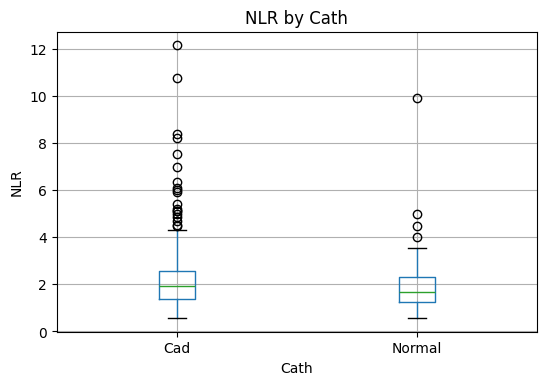

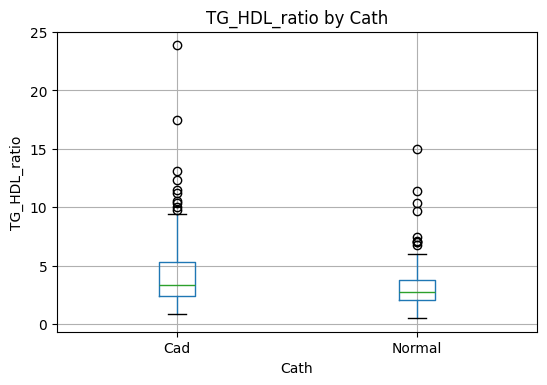

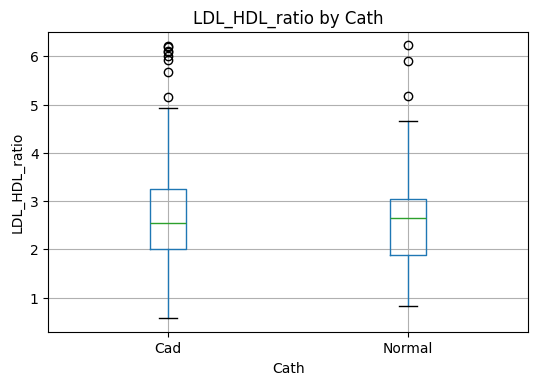

In [16]:
import matplotlib.pyplot as plt

continuous_engineered = [
    "NLR",
    "TG_HDL_ratio",
    "LDL_HDL_ratio"
]

for col in continuous_engineered:
    if col not in X.columns:
        continue

    temp = pd.DataFrame({
        col: X[col],
        "Cath": df["Cath"]
    })

    temp.boxplot(
        column=col,
        by="Cath",
        figsize=(6, 4)
    )

    plt.title(f"{col} by Cath")
    plt.suptitle("")
    plt.xlabel("Cath")
    plt.ylabel(col)

    plt.show()

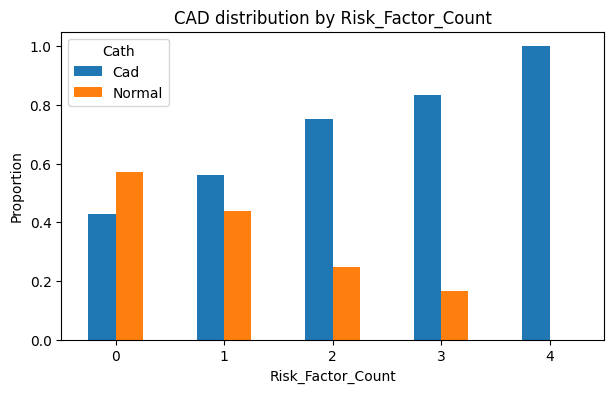

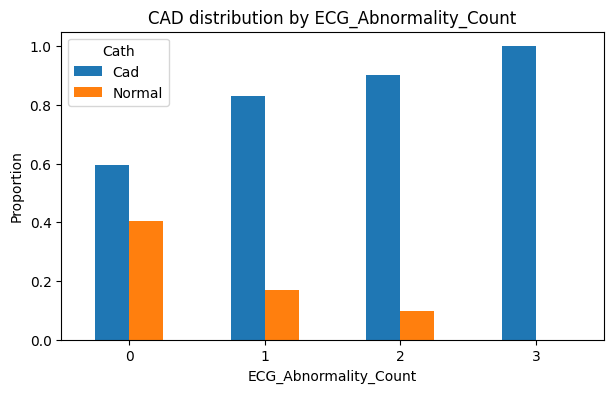

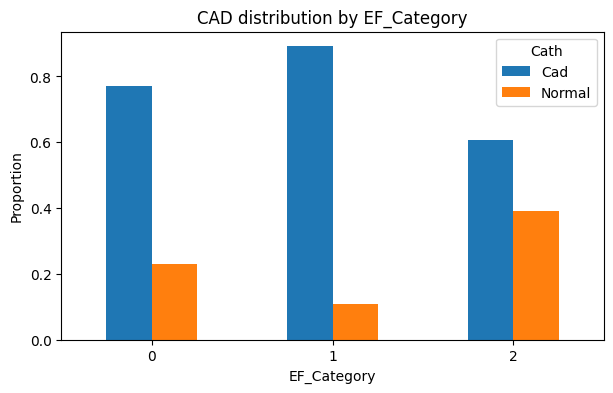

In [17]:
count_engineered = [
    "Risk_Factor_Count",
    "ECG_Abnormality_Count",
    "Symptom_Count",
    "EF_Category"
]

for col in count_engineered:
    if col not in X.columns:
        continue

    table = pd.crosstab(
        X[col],
        df["Cath"],
        normalize="index"
    )

    table.plot(
        kind="bar",
        figsize=(7, 4)
    )

    plt.title(f"CAD distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)

    plt.show()